**Useful Documentation Links**
* pandas: https://pandas.pydata.org/docs/reference/index.html
* scikitlearn: https://scikit-learn.org/stable/api/index.html
* feature engine: https://feature-engine.trainindata.com/en/latest/api_doc/index.html
* mlxtend: https://rasbt.github.io/mlxtend/api_subpackages/mlxtend.feature_selection/
* sklearn-genetic-opt: https://sklearn-genetic-opt.readthedocs.io/en/stable/tutorials/basic_usage.html




In [1]:
!pip install feature_engine
!pip install mlxtend
!pip install sklearn-genetic-opt
!pip install scikit-learn==1.4

  Using cached scikit_learn-1.4.0-1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.4.0-1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.1 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [5]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import plotly.express as px
%matplotlib inline

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import SVC
import missingno as msno

from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder,StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer


import adsa_utils as ad

# UNIQUENESS/REDUNDANCY RANKING METHODS
- we are going to use the sonar dataset which has few good redundant attributes
- because we look for attributes that hold unique information, we will not use the class label column.

In [6]:
## load sonar data
sonar = pd.read_csv('data/sonar.csv', sep=';')
sonar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   attribute_1   208 non-null    float64
 1   attribute_2   208 non-null    float64
 2   attribute_3   208 non-null    float64
 3   attribute_4   208 non-null    float64
 4   attribute_5   208 non-null    float64
 5   attribute_6   208 non-null    float64
 6   attribute_7   208 non-null    float64
 7   attribute_8   208 non-null    float64
 8   attribute_9   208 non-null    float64
 9   attribute_10  208 non-null    float64
 10  attribute_11  208 non-null    float64
 11  attribute_12  208 non-null    float64
 12  attribute_13  208 non-null    float64
 13  attribute_14  208 non-null    float64
 14  attribute_15  208 non-null    float64
 15  attribute_16  208 non-null    float64
 16  attribute_17  208 non-null    float64
 17  attribute_18  208 non-null    float64
 18  attribute_19  208 non-null    

In [7]:
# 1. generate correlations (without the label column)
correlation = sonar[sonar.columns.difference(['class'])].corr()
correlation

,attribute_1,attribute_10,attribute_11,attribute_12,attribute_13,attribute_14,attribute_15,attribute_16,attribute_17,attribute_18,...,attribute_55,attribute_56,attribute_57,attribute_58,attribute_59,attribute_6,attribute_60,attribute_7,attribute_8,attribute_9
attribute_1,1.000000,0.318276,0.344058,0.210861,0.210722,0.256278,0.304878,0.239079,0.137845,0.041817,...,0.312067,0.220642,0.313725,0.368132,0.357116,0.238921,0.347078,0.260815,0.355523,0.353420
attribute_10,0.318276,1.000000,0.853140,0.485392,0.405370,0.345684,0.294699,0.242869,0.121264,0.063745,...,0.175254,0.151889,0.140327,0.212277,0.058273,0.288621,0.097358,0.425448,0.652525,0.877131
attribute_11,0.344058,0.853140,1.000000,0.781164,0.646978,0.460504,0.356516,0.304069,0.237679,0.191567,...,0.228991,0.122332,0.103405,0.193358,0.067726,0.333570,0.089695,0.396588,0.584583,0.728063
attribute_12,0.210861,0.485392,0.781164,1.000000,0.827106,0.467793,0.281758,0.245383,0.250611,0.241910,...,0.164590,0.115658,0.030732,0.065273,0.044614,0.344451,0.071364,0.274432,0.328329,0.363404
attribute_13,0.210722,0.405370,0.646978,0.827106,1.000000,0.756758,0.530892,0.465977,0.438185,0.394510,...,0.272492,0.183743,0.057870,0.171140,0.151804,0.411107,0.061411,0.365391,0.322951,0.316899
attribute_14,0.256278,0.345684,0.460504,0.467793,0.756758,1.000000,0.869733,0.747277,0.636990,0.560637,...,0.326821,0.252166,0.190886,0.258675,0.209122,0.396233,0.120966,0.409576,0.387114,0.329659
attribute_15,0.304878,0.294699,0.356516,0.281758,0.530892,0.869733,1.000000,0.912625,0.749942,0.632139,...,0.261822,0.218395,0.202511,0.225545,0.193671,0.367908,0.171089,0.411692,0.391514,0.299575
attribute_16,0.239079,0.242869,0.304069,0.245383,0.465977,0.747277,0.912625,1.000000,0.899234,0.774855,...,0.240968,0.215478,0.191736,0.198019,0.182337,0.353783,0.158438,0.363086,0.322237,0.241819
attribute_17,0.137845,0.121264,0.237679,0.250611,0.438185,0.636990,0.749942,0.899234,1.000000,0.925836,...,0.168460,0.128968,0.145708,0.148563,0.121800,0.293190,0.093992,0.250024,0.140912,0.100146
attribute_18,0.041817,0.063745,0.191567,0.241910,0.394510,0.560637,0.632139,0.774855,0.925836,1.000000,...,0.093767,0.080812,0.056930,0.096022,0.028446,0.235778,0.046617,0.208057,0.061333,0.027380


In [8]:
# 2. square each correlation
sq_correlation = correlation * correlation
sq_correlation

,attribute_1,attribute_10,attribute_11,attribute_12,attribute_13,attribute_14,attribute_15,attribute_16,attribute_17,attribute_18,...,attribute_55,attribute_56,attribute_57,attribute_58,attribute_59,attribute_6,attribute_60,attribute_7,attribute_8,attribute_9
attribute_1,1.000000,0.101299,0.118376,0.044462,0.044404,0.065678,0.092951,0.057159,0.019001,0.001749,...,9.738609e-02,0.048683,0.098423,0.135521,0.127532,0.057083,0.120463,0.068024,0.126397,0.124906
attribute_10,0.101299,1.000000,0.727848,0.235605,0.164325,0.119497,0.086847,0.058986,0.014705,0.004063,...,3.071406e-02,0.023070,0.019692,0.045061,0.003396,0.083302,0.009479,0.181006,0.425789,0.769358
attribute_11,0.118376,0.727848,1.000000,0.610217,0.418581,0.212064,0.127104,0.092458,0.056491,0.036698,...,5.243697e-02,0.014965,0.010693,0.037387,0.004587,0.111269,0.008045,0.157282,0.341738,0.530075
attribute_12,0.044462,0.235605,0.610217,1.000000,0.684105,0.218831,0.079388,0.060213,0.062806,0.058520,...,2.708989e-02,0.013377,0.000944,0.004261,0.001990,0.118647,0.005093,0.075313,0.107800,0.132063
attribute_13,0.044404,0.164325,0.418581,0.684105,1.000000,0.572682,0.281846,0.217134,0.192006,0.155638,...,7.425206e-02,0.033761,0.003349,0.029289,0.023044,0.169009,0.003771,0.133510,0.104297,0.100425
attribute_14,0.065678,0.119497,0.212064,0.218831,0.572682,1.000000,0.756435,0.558424,0.405756,0.314314,...,1.068120e-01,0.063588,0.036438,0.066913,0.043732,0.157001,0.014633,0.167753,0.149857,0.108675
attribute_15,0.092951,0.086847,0.127104,0.079388,0.281846,0.756435,1.000000,0.832885,0.562414,0.399600,...,6.855091e-02,0.047696,0.041011,0.050871,0.037508,0.135356,0.029271,0.169490,0.153284,0.089745
attribute_16,0.057159,0.058986,0.092458,0.060213,0.217134,0.558424,0.832885,1.000000,0.808621,0.600400,...,5.806543e-02,0.046431,0.036763,0.039212,0.033247,0.125162,0.025103,0.131831,0.103837,0.058476
attribute_17,0.019001,0.014705,0.056491,0.062806,0.192006,0.405756,0.562414,0.808621,1.000000,0.857172,...,2.837881e-02,0.016633,0.021231,0.022071,0.014835,0.085960,0.008834,0.062512,0.019856,0.010029
attribute_18,0.001749,0.004063,0.036698,0.058520,0.155638,0.314314,0.399600,0.600400,0.857172,1.000000,...,8.792221e-03,0.006531,0.003241,0.009220,0.000809,0.055591,0.002173,0.043288,0.003762,0.000750


In [9]:
# 3. add the results
sq_correlation_sum = sq_correlation.sum()
sq_correlation_sum

attribute_1     5.377761
attribute_10    5.123597
attribute_11    5.675621
attribute_12    4.276248
attribute_13    5.772365
attribute_14    7.457322
attribute_15    7.756554
attribute_16    7.901611
attribute_17    7.458724
attribute_18    7.695458
attribute_19    7.716611
attribute_2     6.190148
attribute_20    7.060479
attribute_21    6.449632
attribute_22    6.282001
attribute_23    5.570997
attribute_24    5.420957
attribute_25    5.843045
attribute_26    6.006612
attribute_27    5.930497
attribute_28    5.515436
attribute_29    5.910035
attribute_3     5.691548
attribute_30    5.780751
attribute_31    5.971626
attribute_32    5.895640
attribute_33    6.494642
attribute_34    6.535655
attribute_35    6.466947
attribute_36    6.344590
attribute_37    5.709412
attribute_38    6.755099
attribute_39    6.485521
attribute_4     5.474118
attribute_40    6.129033
attribute_41    7.034718
attribute_42    6.928942
attribute_43    6.627418
attribute_44    6.060244
attribute_45    7.474437


In [10]:
# 4. scale results within [0, 1]
sq_correlation_sum_scaled = (sq_correlation_sum - sq_correlation_sum.min()) / (sq_correlation_sum.max() - sq_correlation_sum.min())
sq_correlation_sum_scaled

attribute_1     0.385369
attribute_10    0.323473
attribute_11    0.457907
attribute_12    0.117119
attribute_13    0.481467
attribute_14    0.891803
attribute_15    0.964674
attribute_16    1.000000
attribute_17    0.892144
attribute_18    0.949796
attribute_19    0.954947
attribute_2     0.583209
attribute_20    0.795160
attribute_21    0.646401
attribute_22    0.605578
attribute_23    0.432428
attribute_24    0.395889
attribute_25    0.498679
attribute_26    0.538513
attribute_27    0.519976
attribute_28    0.418897
attribute_29    0.514993
attribute_3     0.461786
attribute_30    0.483509
attribute_31    0.529993
attribute_32    0.511488
attribute_33    0.657362
attribute_34    0.667350
attribute_35    0.650618
attribute_36    0.620820
attribute_37    0.466136
attribute_38    0.720791
attribute_39    0.655141
attribute_4     0.408835
attribute_40    0.568326
attribute_41    0.788886
attribute_42    0.763127
attribute_43    0.689697
attribute_44    0.551574
attribute_45    0.895971


In [11]:
# 5. invert the results
weights = 1 - sq_correlation_sum_scaled
# optionally display them in descending order
weights.sort_values(ascending=False)

attribute_57    1.000000
attribute_60    0.997248
attribute_53    0.978548
attribute_56    0.945673
attribute_54    0.887713
attribute_12    0.882881
attribute_6     0.880362
attribute_7     0.858837
attribute_52    0.792536
attribute_55    0.789617
attribute_5     0.773742
attribute_51    0.720206
attribute_58    0.710411
attribute_50    0.699456
attribute_10    0.676527
attribute_59    0.667745
attribute_9     0.663577
attribute_8     0.617070
attribute_1     0.614631
attribute_24    0.604111
attribute_4     0.591165
attribute_28    0.581103
attribute_23    0.567572
attribute_11    0.542093
attribute_3     0.538214
attribute_37    0.533864
attribute_13    0.518533
attribute_30    0.516491
attribute_25    0.501321
attribute_32    0.488512
attribute_29    0.485007
attribute_27    0.480024
attribute_31    0.470007
attribute_26    0.461487
attribute_44    0.448426
attribute_40    0.431674
attribute_2     0.416791
attribute_22    0.394422
attribute_49    0.392925
attribute_36    0.379180


# RELEVANCE RANKING METHODS
## **Clasification Context**
- this time we will use the class label column.
- we will use a linear SVM

In [12]:
# separate the reg.attr. from the label attr.
X = sonar[sonar.columns.difference(['class'])]
y = sonar[['class']]
# split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [13]:
# model baseline using a linear SVM
svm_clf = SVC(kernel='linear', random_state=43)
# crossvalidate on the train portion using the custom function
ad.cross_validation_avg_scores(X_train, y_train, svm_clf)
y_pred = svm_clf.predict(X_test)
print(classification_report(y_test, y_pred))

Mean Accuracy is 80.75 +/- 6.71
Mean Precision is 81.67 +/- 6.79
Mean Recall is 79.75 +/- 6.91
Mean F-score is 80.05 +/- 7.00
              precision    recall  f1-score   support

        Mine       0.70      0.80      0.74        20
        Rock       0.79      0.68      0.73        22

    accuracy                           0.74        42
   macro avg       0.74      0.74      0.74        42
weighted avg       0.74      0.74      0.74        42




## Feature Weighting and Selection for Classification

- there are 3 ranking methods in sklearn which can be used to output weights:
1. f_classif estimates the degree of linear dependency between 2 variables
  - it computes the anova F-values between each variable and the class label attribute.
2. chi2 estimates the degree of dependency between nominal variables (in sklearn these are non-negative attributes since these variables are typically converted to numeric variables)
  - it looks at each feature and estimates how likely are they to be independent of the class label column, i.e., irrelevant attributes.
3. mutual_info_classif also measure the extent to which 2 variables are dependent, whith higher scores indicating higher level of dependency
  - it computes a score for each regular attribute in relation to the class label attribute


- there are several sklearn classes that allows us to performance feature selection with ranking methods, including:
1. SelectKBest - selects the k highest scoring attributes (using any of the weigthing schemes above)
2. SelectPercentile selects the user-specified highest scoring percentage of features
3. GenericUnivariateSelect allows to select the best univariate selection strategy with hyper-parameter search estimator

- we will use the third option which allows us to get not only the weights of attributes, but also the p-values, so the higher the weight and the lower the p-value, the more predictive a feature is.
- it also allows us to specify the selection mode:
  - percentile: selects features based on percentile of the highest scores.
  - k_best: selects features based on the k highest scores.
  - fpr: selects features based on a false positive rate test.
  - fdr: selects features based on an estimated false discovery rate.
  - fwe: selects features based on family-wise error rate.

In [14]:
from sklearn.feature_selection import GenericUnivariateSelect

"""
function to get the weights and p-values of each feature
using one of the univariate approaches;
it takes in the regular attributes data, the class label columns,
the weighting strategy and the selection mode;
it then looks at all features and returns the weights and p-values in a dataframe
"""
def feature_ranking(X, y, strategy, mode):
  X_selected = GenericUnivariateSelect(strategy, mode=mode, param='all').fit(X, y)
  ## build the dataframe for scores
  scores = pd.DataFrame(X_selected.scores_)
  columns = pd.DataFrame(X.columns)
  attr_scores = pd.concat([columns, scores], axis=1)
  attr_scores.columns = ['attribute', 'weight']
  attr_scores['p-value'] = X_selected.pvalues_
  return attr_scores

In [15]:
# 1. using the f-classif weighting strategy
# we will use k_best which by default is set to all features
from sklearn.feature_selection import f_classif
anova_scores = feature_ranking(X_train, y_train, f_classif, 'k_best')
anova_scores.sort_values(by='weight', ascending=False)


,attribute,weight,p-value
2,attribute_11,33.042057,4.293601e-08
3,attribute_12,27.773696,4.242737e-07
43,attribute_49,23.339821,3.096550e-06
46,attribute_51,22.234733,5.129274e-06
39,attribute_45,22.047722,5.588745e-06
47,attribute_52,20.531252,1.125350e-05
40,attribute_46,20.055577,1.403876e-05
1,attribute_10,17.884268,3.891768e-05
42,attribute_48,17.102129,5.643078e-05
41,attribute_47,16.747873,6.682590e-05


In [16]:
9.899392e-01

0.9899392

30


<Axes: xlabel='attribute', ylabel='weight'>

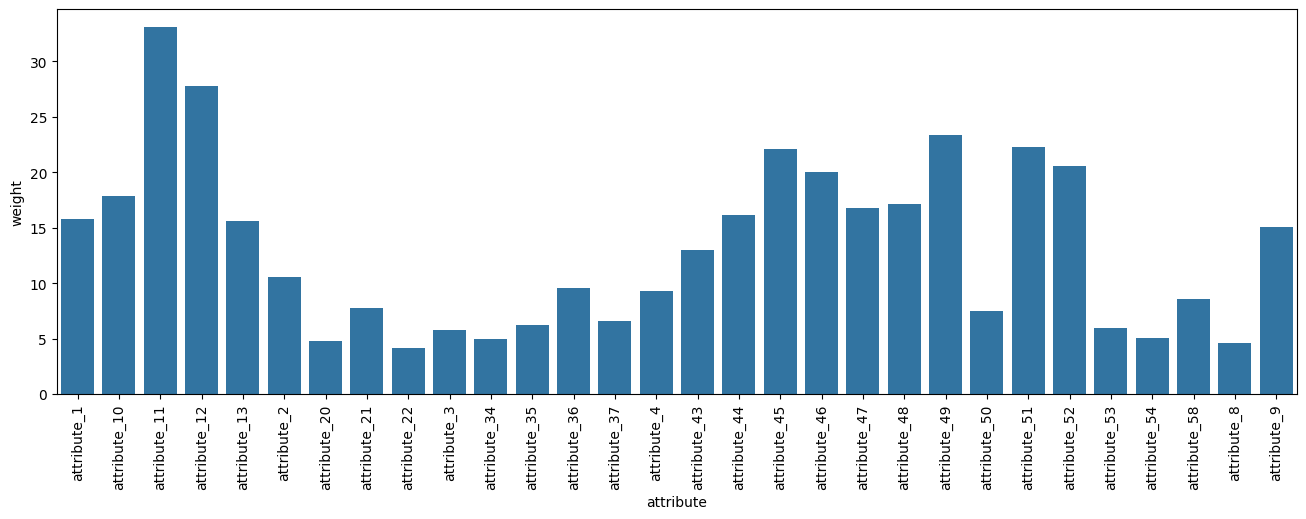

In [17]:
# get the attributes for which p-values are below 0.05
low_p_attr = anova_scores[anova_scores['p-value'] < 0.05]
print(len(low_p_attr))
# plot their weights
fig, ax = plt.subplots(figsize=(16, 5))
plt.xticks(rotation=90)
sns.barplot(low_p_attr, x="attribute", y="weight", ax=ax)

In [18]:
# we can then use only those attributes in the model
ad.cross_validation_avg_scores(X_train[list(low_p_attr.attribute)], y_train, svm_clf)
y_pred = svm_clf.predict(X_test[list(low_p_attr.attribute)])
print(classification_report(y_test, y_pred))

Mean Accuracy is 80.12 +/- 7.31
Mean Precision is 81.06 +/- 6.99
Mean Recall is 79.39 +/- 7.67
Mean F-score is 79.45 +/- 7.65
              precision    recall  f1-score   support

        Mine       0.69      0.90      0.78        20
        Rock       0.88      0.64      0.74        22

    accuracy                           0.76        42
   macro avg       0.78      0.77      0.76        42
weighted avg       0.79      0.76      0.76        42



In [16]:
# EXERCISE: apply the same approach using chi2 and mutual_info_classif.

- to avoid leakage, another approach is to use the feature selection as part of a classification pipeline which can be crossvalidated, so performance scores can be retrieved, e.g. accuracy (other metrics can be used)
- we will go over an example that uses a SVC as the classifier, chi2 strategy, and percentile selection mode, but any combination can be done using this approach

In [17]:
from sklearn.feature_selection import SelectPercentile
from sklearn.feature_selection import chi2
prep = SelectPercentile(chi2, percentile=75)
ad.cross_val_pipeline(svm_clf, prep, X_train, y_train)


Mean Accuracy is 78.36 +/- 8.04
Mean Precision is 78.64 +/- 8.09
Mean Recall is 77.56 +/- 8.42
Mean F-score is 77.69 +/- 8.48


In [18]:
# or we can search for optimal set of hyperparameters within a range
from sklearn.feature_selection import mutual_info_classif
params = {
    'rank__score_func': [f_classif, chi2, mutual_info_classif],
    'rank__mode': ['k_best', 'percentile'],
}
pipeline = Pipeline([
    ('rank', GenericUnivariateSelect()),
    ('classifier', svm_clf)
])
grid = GridSearchCV(pipeline, param_grid=params)
grid.fit(X_train, y_train)
grid.best_params_

{'rank__mode': 'percentile',
 'rank__score_func': <function sklearn.feature_selection._mutual_info.mutual_info_classif(X, y, *, discrete_features='auto', n_neighbors=3, copy=True, random_state=None)>}

In [19]:
# EXERCISE: apply the best set of hyperparameters to the test portion and discuss performance

# EXERCISE: use similar processes, but in the context of regression for which you need a datset with a numeric target variable
# the corresponding univariate strategies you can try are r_regression, f_regression, and mutual_info_regression

# Wrapper Feature Weighting and Selection
- we look at 3 approaches:
1. **sequential backwards FS** with sklearn
2. **sequential forward FS** with sklearn
- Notes:
  - these approaches can be used with any learner
  - in sklearn, they are facilitated by the class SequentialFeatureSelector which adds (forward selection) or removes (backward selection) features to form a feature subset in a greedy fashion. At each stage, it chooses the best feature to add or remove based on the cross-validation score of a learner.
  - there are several hyperparameters of interest:
    - estimator - this specifies the learner/classifier
    - n_features_to_select: “auto”, int or float, default=”auto”; typically, auto selects half the features, but this depends on another hyperparameter; if an integer is specified, then that represents the number of features to retain; if float (between 0 and 1) is specified, that represents the fraction of features to be selected.
    - tol: float, default=None - represents the threshold score for adding/removing features; it is enabled only when n_features_to_select is "auto".
    - direction: ‘forward’, ‘backward’; default=’forward’; this specifies whether the approach taken is forward or backwards
3. **genetic algorithm based FS** with sklearn-genetic-opt
  - Now we can create the GAFeatureSelectionCV object, it’s very similar to the GASearchCV and they share most of the parameters, the main difference is GAFeatureSelectionCV doesn’t run hyperparameters optimization thus the param_grid parameter it’s not available, and the estimator should be defined with its hyperparameters.
  - The way the feature selection is performed is by creating models with a subsample of features and evaluate its cv-score, the way the subsets are created is by using the available evolutionary algorithms. It also tries to minimize the number of selected features, so it’s a multi-objective optimization.

- **NOTE**: all have built in crossvalidation; by default, the number of folds is set to 5 folds

In [20]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn_genetic import GAFeatureSelectionCV

In [21]:
# 1. forward FS with svm, but it can be done with any classification algorithm
seq_ffs = SequentialFeatureSelector(svm_clf)
forward_X = seq_ffs.fit_transform(X_train, y_train)
forward_X = pd.DataFrame(forward_X, columns=seq_ffs.get_feature_names_out())
forward_X.head()

,attribute_1,attribute_11,attribute_12,attribute_14,attribute_15,attribute_16,attribute_2,attribute_20,attribute_24,attribute_25,...,attribute_53,attribute_54,attribute_55,attribute_56,attribute_57,attribute_58,attribute_59,attribute_6,attribute_60,attribute_7
0,0.0139,0.1261,0.0828,0.0848,0.1514,0.1396,0.0222,0.3247,0.8757,0.9048,...,0.0072,0.0113,0.0012,0.0022,0.0025,0.0059,0.0039,0.0136,0.0048,0.0659
1,0.0411,0.1370,0.1335,0.1526,0.0775,0.1196,0.0277,0.2975,0.3202,0.3452,...,0.0038,0.0019,0.0065,0.0132,0.0108,0.0050,0.0085,0.0385,0.0044,0.0611
2,0.0731,0.1739,0.3160,0.2164,0.2031,0.2580,0.1249,0.1810,0.9757,0.8079,...,0.0230,0.0290,0.0141,0.0161,0.0177,0.0194,0.0207,0.2770,0.0057,0.2555
3,0.0116,0.3171,0.2882,0.2307,0.1889,0.1791,0.0744,0.7260,0.9173,0.9327,...,0.0103,0.0100,0.0034,0.0026,0.0037,0.0044,0.0057,0.0545,0.0035,0.1110
4,0.0378,0.3135,0.3118,0.3885,0.5850,0.7868,0.0318,0.8610,0.4033,0.5946,...,0.0044,0.0078,0.0102,0.0065,0.0061,0.0062,0.0043,0.1635,0.0053,0.0887


In [22]:
ad.cross_validation_avg_scores(forward_X, y_train, svm_clf)
y_pred = svm_clf.predict(X_test[forward_X.columns])
print(classification_report(y_test, y_pred))

Mean Accuracy is 78.95 +/- 5.59
Mean Precision is 80.23 +/- 5.59
Mean Recall is 77.75 +/- 5.89
Mean F-score is 78.00 +/- 6.02
              precision    recall  f1-score   support

        Mine       0.68      0.85      0.76        20
        Rock       0.82      0.64      0.72        22

    accuracy                           0.74        42
   macro avg       0.75      0.74      0.74        42
weighted avg       0.76      0.74      0.74        42



In [23]:
# 2. backwards FS with svm
seq_bfs = SequentialFeatureSelector(svm_clf, direction='backward')
backward_X = seq_bfs.fit_transform(X_train, y_train)
backward_X = pd.DataFrame(backward_X, columns=seq_bfs.get_feature_names_out())
backward_X.head()

,attribute_10,attribute_11,attribute_12,attribute_15,attribute_20,attribute_21,attribute_22,attribute_24,attribute_26,attribute_27,...,attribute_42,attribute_43,attribute_44,attribute_46,attribute_47,attribute_48,attribute_49,attribute_5,attribute_8,attribute_9
0,0.1015,0.1261,0.0828,0.1514,0.3247,0.3797,0.5658,0.8757,0.7511,0.6858,...,0.2112,0.1513,0.1789,0.1717,0.0898,0.0656,0.0445,0.0215,0.0954,0.0786
1,0.2300,0.1370,0.1335,0.0775,0.2975,0.2836,0.3353,0.3202,0.3562,0.3892,...,0.3492,0.2662,0.3137,0.4262,0.3511,0.2458,0.1259,0.0489,0.1117,0.1237
2,0.1114,0.1739,0.3160,0.2031,0.1810,0.2604,0.6572,0.9757,0.6521,0.4915,...,0.4463,0.3178,0.0807,0.2134,0.3241,0.2945,0.1474,0.1443,0.1712,0.0466
3,0.2271,0.3171,0.2882,0.1889,0.7260,0.7934,0.8045,0.9173,0.9562,1.0000,...,0.0469,0.1476,0.1742,0.1651,0.1181,0.0720,0.0321,0.0076,0.1069,0.1708
4,0.2053,0.3135,0.3118,0.5850,0.8610,0.8443,0.9061,0.4033,0.6793,0.6389,...,0.2714,0.1713,0.0584,0.2200,0.2198,0.1074,0.0423,0.1787,0.0817,0.1779


In [24]:
ad.cross_validation_avg_scores(backward_X, y_train, svm_clf)
y_pred = svm_clf.predict(X_test[backward_X.columns])
print(classification_report(y_test, y_pred))

Mean Accuracy is 82.51 +/- 7.05
Mean Precision is 83.88 +/- 6.55
Mean Recall is 81.50 +/- 7.44
Mean F-score is 81.73 +/- 7.60
              precision    recall  f1-score   support

        Mine       0.73      0.80      0.76        20
        Rock       0.80      0.73      0.76        22

    accuracy                           0.76        42
   macro avg       0.76      0.76      0.76        42
weighted avg       0.77      0.76      0.76        42



In [25]:
# 3. evolutionary FS with svm; leave the rest to default values
ev_fs = GAFeatureSelectionCV(svm_clf, verbose=False)
evol_X = ev_fs.fit_transform(X_train, y_train)
evol_X = pd.DataFrame(evol_X, columns=X_train.columns[ev_fs.support_])
evol_X.head()

,attribute_10,attribute_12,attribute_14,attribute_15,attribute_16,attribute_21,attribute_23,attribute_3,attribute_31,attribute_34,...,attribute_49,attribute_50,attribute_51,attribute_53,attribute_56,attribute_57,attribute_58,attribute_59,attribute_6,attribute_8
0,0.1015,0.0828,0.0848,0.1514,0.1396,0.3797,0.7483,0.0089,0.2206,0.2907,...,0.0445,0.0110,0.0024,0.0072,0.0022,0.0025,0.0059,0.0039,0.0136,0.0954
1,0.2300,0.1335,0.1526,0.0775,0.1196,0.2836,0.3622,0.0604,0.8528,0.4012,...,0.1259,0.0327,0.0181,0.0038,0.0132,0.0108,0.0050,0.0085,0.0385,0.1117
2,0.1114,0.3160,0.2164,0.2031,0.2580,0.2604,0.9734,0.1665,0.5101,0.1906,...,0.1474,0.0211,0.0361,0.0230,0.0161,0.0177,0.0194,0.0207,0.2770,0.1712
3,0.2271,0.2882,0.2307,0.1889,0.1791,0.7934,0.8067,0.0367,0.3997,0.2413,...,0.0321,0.0056,0.0202,0.0103,0.0026,0.0037,0.0044,0.0057,0.0545,0.1069
4,0.2053,0.3118,0.3885,0.5850,0.7868,0.8443,0.5847,0.0423,0.4729,0.3894,...,0.0423,0.0162,0.0093,0.0044,0.0065,0.0061,0.0062,0.0043,0.1635,0.0817


In [26]:
ad.cross_validation_avg_scores(evol_X, y_train, svm_clf)
y_pred = svm_clf.predict(X_test[evol_X.columns])
print(classification_report(y_test, y_pred))

Mean Accuracy is 80.14 +/- 6.99
Mean Precision is 83.86 +/- 6.15
Mean Recall is 78.44 +/- 7.56
Mean F-score is 78.56 +/- 7.76
              precision    recall  f1-score   support

        Mine       0.72      0.90      0.80        20
        Rock       0.88      0.68      0.77        22

    accuracy                           0.79        42
   macro avg       0.80      0.79      0.78        42
weighted avg       0.81      0.79      0.78        42



In [28]:
# EXERCISE: try out different classification algorithms and other hyperparameters'
# values for each of the 3 approaches, retrieve performance, compare and discuss.

# EXERCISE: try out different regression algorithms on the poly data with various hyperparameters'
# values for each of the 3 approaches, retrieve performance, compare and discuss.

# OPTIONAL EXERCISE: try out the brute force algorithm with different min_features
# and max_features; retrieve performance for each, compare and discuss.

# EMBEDDED METHODS: Feature Weighting/Importance as a built-in feature of a classification/prediction algorithm
- many classification/prediction algorithms also output feature weights
- we will use **SelectFromModel** class to implement 2 types of embedded methods for FS:
  - <u>L1-based feature selection</u> - suitable for datasets with linear relationships; algorithms that can be used are those that have the attribute coef_, e.g., LogisticRegression and LinearSVC for classification, or linear regression algorithms such as ridge and lasso.  
  - <u>tree based</u> - can capture any relationship; it computes feature importance based on impurity measures usch as entropy, or gini exposed through feature_importances attribute; so any tree based algorithm can be used, including DeciosionTreeClassifier, XGBoost, ExtraTreesClassifier, RandomForest, etc.

 <u>NOTE:</u> - NaiveBayes exposes feature importance through the attribute feature_log_prob_

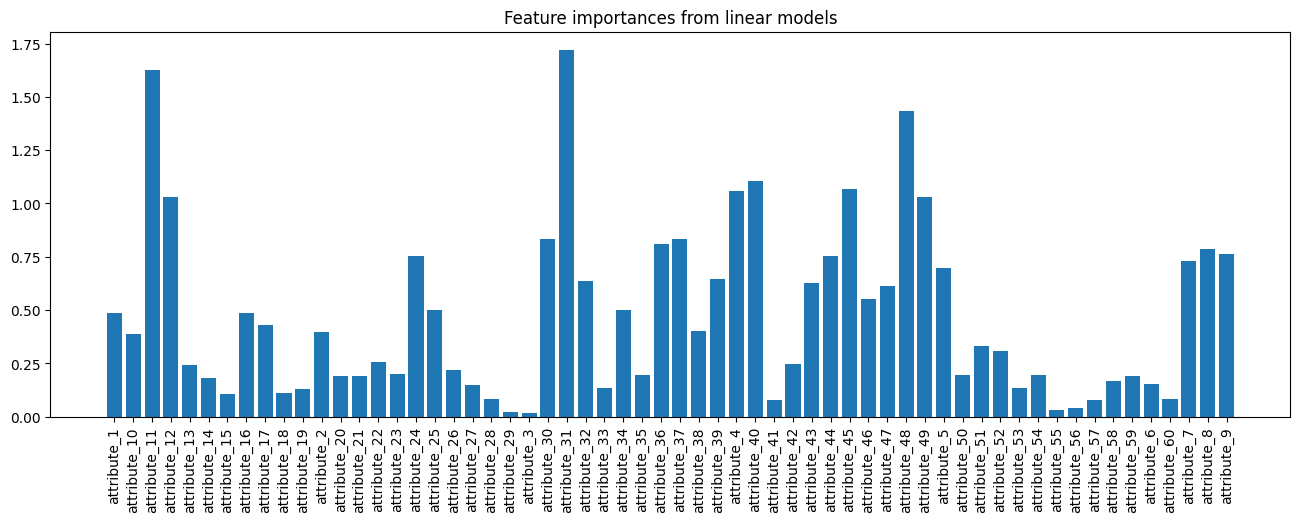

In [29]:
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

# can use feature importances as exploratory tool
linear_svm = LinearSVC(random_state=43)
linear_svm.fit(X, y)
importances = np.abs(linear_svm.coef_[0])
plt.figure(figsize=(16, 5))
plt.bar(height=importances, x=X.columns)
plt.title("Feature importances from linear models")
plt.xticks(rotation=90)
plt.show()

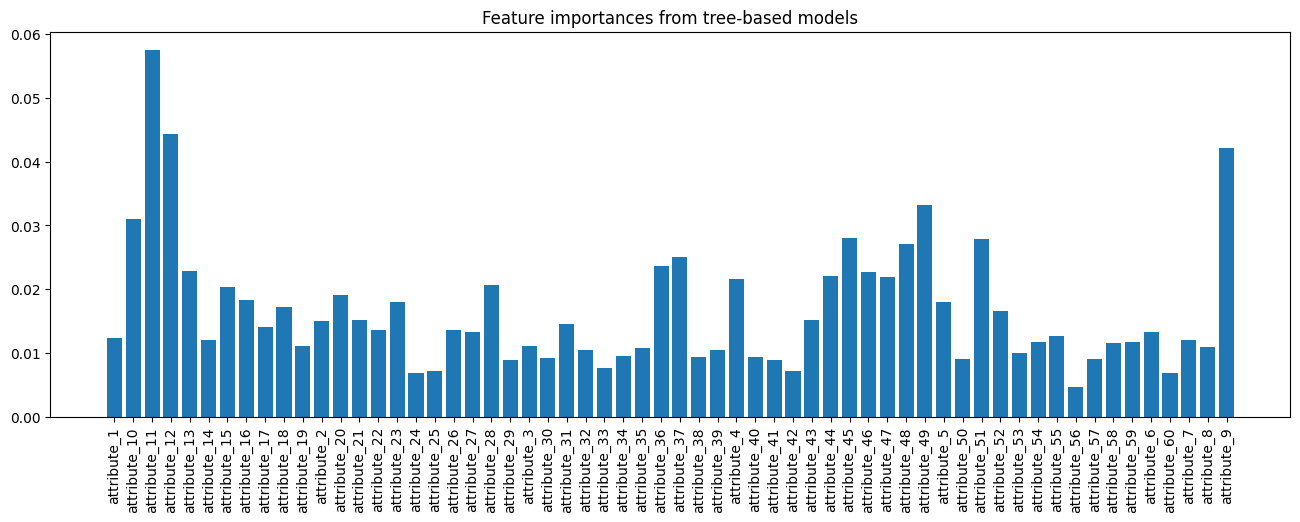

In [30]:
# can use feature importances as exploratory tool
rf = RandomForestClassifier(criterion='entropy', random_state=43)
rf.fit(X, y)
importances = np.abs(rf.feature_importances_)
plt.figure(figsize=(16, 5))
plt.bar(height=importances, x=X.columns)
plt.title("Feature importances from tree-based models")
plt.xticks(rotation=90)
plt.show()

In [31]:
# alternatively, we can create a dataframe with certain attributes and score
attr_scores = pd.DataFrame({"attribute": X.columns, "weight": rf.feature_importances_})
attr_scores.sort_values(by='weight', ascending=False)

,attribute,weight
2,attribute_11,0.057532
3,attribute_12,0.044394
59,attribute_9,0.042132
43,attribute_49,0.033155
1,attribute_10,0.031000
39,attribute_45,0.028047
46,attribute_51,0.027842
42,attribute_48,0.027083
30,attribute_37,0.025110
29,attribute_36,0.023701


In [32]:
# we can use SelectFromModel to retain only important features
# 1. linear
linear_selector = SelectFromModel(linear_svm)
linear_X = linear_selector.fit_transform(X_train, y_train)
selected_features = [col for index, col in enumerate(X_train.columns)
            if index in linear_selector.get_support(indices=True)]
linear_X = pd.DataFrame(linear_X, columns=selected_features)
ad.cross_validation_avg_scores(linear_X, y_train, linear_svm)
y_pred = linear_svm.predict(X_test[linear_X.columns])
print(classification_report(y_test, y_pred))
print(linear_X.columns, len(linear_X.columns))

Mean Accuracy is 81.91 +/- 6.68
Mean Precision is 81.86 +/- 6.74
Mean Recall is 81.73 +/- 6.67
Mean F-score is 81.73 +/- 6.69
              precision    recall  f1-score   support

        Mine       0.76      0.80      0.78        20
        Rock       0.81      0.77      0.79        22

    accuracy                           0.79        42
   macro avg       0.79      0.79      0.79        42
weighted avg       0.79      0.79      0.79        42

Index(['attribute_1', 'attribute_11', 'attribute_12', 'attribute_13',
       'attribute_21', 'attribute_24', 'attribute_25', 'attribute_31',
       'attribute_32', 'attribute_34', 'attribute_36', 'attribute_37',
       'attribute_39', 'attribute_4', 'attribute_40', 'attribute_43',
       'attribute_44', 'attribute_45', 'attribute_46', 'attribute_48',
       'attribute_49', 'attribute_7', 'attribute_8', 'attribute_9'],
      dtype='object') 24


In [33]:
# we can use SelectFromModel to retain only important features
# 2. tree based
tree_selector = SelectFromModel(rf)
tree_X = tree_selector.fit_transform(X_train, y_train)
selected_features = [col for index, col in enumerate(X_train.columns)
            if index in tree_selector.get_support(indices=True)]
tree_X = pd.DataFrame(tree_X, columns=selected_features)
ad.cross_validation_avg_scores(tree_X, y_train, rf)
y_pred = rf.predict(X_test[tree_X.columns])
print(classification_report(y_test, y_pred))
print(tree_X.columns, len(tree_X.columns))

Mean Accuracy is 81.35 +/- 4.69
Mean Precision is 81.65 +/- 4.41
Mean Recall is 80.89 +/- 5.07
Mean F-score is 80.94 +/- 5.00
              precision    recall  f1-score   support

        Mine       0.76      0.80      0.78        20
        Rock       0.81      0.77      0.79        22

    accuracy                           0.79        42
   macro avg       0.79      0.79      0.79        42
weighted avg       0.79      0.79      0.79        42

Index(['attribute_10', 'attribute_11', 'attribute_12', 'attribute_13',
       'attribute_17', 'attribute_28', 'attribute_31', 'attribute_37',
       'attribute_43', 'attribute_45', 'attribute_46', 'attribute_47',
       'attribute_49', 'attribute_51', 'attribute_52', 'attribute_9'],
      dtype='object') 16


In [35]:
# EXERCISE: experiment with different hyperparameters of SelectFromModel in the
# context of both classification and regression

# **OPTIONAL**

## Recursive feature elimination
- selects features by recursively considering smaller and smaller sets of fearures using a specific classifier, e.g., decision tree
  - the classifier is trained with all features initially, and their importance is obtained
  - then the least important features are pruned from the current set of features
  - then the classifier is trained with the remaining features, and their importance is obtained
  - then the least important features are pruned from the current set of features
  - and so on until the desired number of features to select is eventually reached.
  - it gives an insight into how the features were selected using the ranking_ attribute
  - apart from the learner, there are 2 other hyperparameters of interest:
    - step: int or float, default=1; if specified as integer, this represents the number of features to remove in each iteration; if specified as a float between 0 and 1, this represents the fraction of features to be removed in each iteration
    - min_features_to_select: int, default=1; it represents the minimum number of features to be selected.
- we will use the version with built in crossvalidation (from sklearn)

In [36]:
# 3. recursive feature selection with LogisticRegression as exploratory tool
# we specify step = 1, so that removes 1 feature in each iteration
from sklearn.feature_selection import RFECV
rfs = RFECV(LogisticRegression(random_state=43), step=1)
rfs_X = rfs.fit_transform(X, y)
print(rfs_X.shape)

(208, 6)


In [37]:
features_ranks = zip(rfs.get_feature_names_out(), rfs.ranking_)
for feature, rank in features_ranks:
  print(feature, '-', rank)

attribute_11 - 33
attribute_12 - 4
attribute_36 - 1
attribute_44 - 1
attribute_45 - 16
attribute_46 - 54


## Class Weigthing and Cost Sensitive Learning
- useful to deal with class imbalance
- we can use the built in parameters of certain algorithms:
  1. xgboost has a param called scale_pos_weight which by default is 1; for unbalanced datasets in binary classification tasks, typically, the following formula is used: number_of_negative_rows/number_of_positive_rows
  2. many sklearn algorithms, such as decision tree and svm, have the class_weight parameter which by default is none which means all classes have a weight of 1; we can specify 'balanced' which sets the weights inversely proportional to class frequencies, or we can even specify custom weights using a dictionary datastructure, e.g.,  {'class1': 0.5, 'class2': 1, 'class3': 2, ...}


In [38]:
cancer = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Work 2024-2025/DataPreparation/breast-cancer.csv')
cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

<Axes: xlabel='diagnosis'>

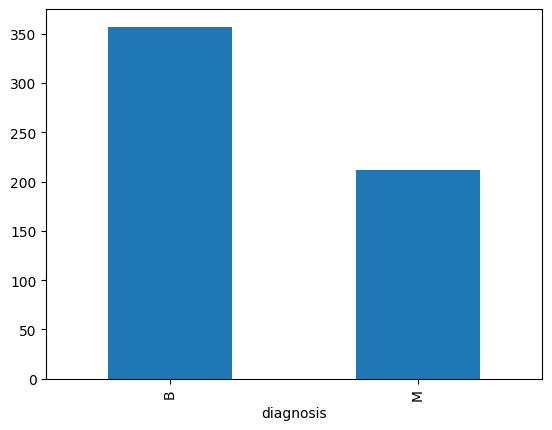

In [39]:
# visualise class imbalance
cancer.diagnosis.value_counts().plot.bar()

In [40]:
X = cancer[cancer.columns.difference(['diagnosis', 'id'])]
y = cancer[['diagnosis']]
y_encoded = y.apply(LabelEncoder().fit_transform)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)
y_train_encoded, y_test_encoded = train_test_split(y_encoded, test_size=0.2, random_state=43)

In [41]:
# 1.1 using xgboost default 'scale_pos_weight'
import xgboost as xgb
xgb_clf = xgb.XGBClassifier(n_estimators=1, num_boost_rounds=1)
ad.cross_validation_avg_scores(X_train, y_train_encoded, xgb_clf)
cross_validation_predictions = cross_val_predict(xgb_clf, X_test, y_test_encoded)
print(classification_report(y_test_encoded, cross_validation_predictions))

Mean Accuracy is 91.43 +/- 2.13
Mean Precision is 91.84 +/- 1.90
Mean Recall is 90.06 +/- 2.90
Mean F-score is 90.69 +/- 2.49
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        75
           1       0.97      0.92      0.95        39

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [42]:
# 1.2 set xgboost 'scale_pos_weight' to number_of_negative_rows/number_of_positive_rows
class_ratio = np.sum(y_encoded == 0)/np.sum(y_encoded == 1)
xgb_clf = xgb.XGBClassifier(n_estimators=1, num_boost_rounds=1,
                            scale_pos_weight=float(class_ratio))
ad.cross_validation_avg_scores(X_train, y_train_encoded, xgb_clf)
cross_validation_predictions = cross_val_predict(xgb_clf, X_test, y_test_encoded)
print(classification_report(y_test_encoded, cross_validation_predictions))

Mean Accuracy is 92.75 +/- 2.26
Mean Precision is 92.35 +/- 2.07
Mean Recall is 92.49 +/- 2.97
Mean F-score is 92.29 +/- 2.50
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        75
           1       0.97      0.92      0.95        39

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [43]:
# search for the best ratio of class weight using grid search
from sklearn.model_selection import GridSearchCV
params = {'scale_pos_weight': [class_ratio, 0.5, 1, 10, 25, 50, 75, 99, 100, 1000] }
xgb_clf = xgb.XGBClassifier(n_estimators=1, num_boost_rounds=1)
grid_search = GridSearchCV(xgb_clf, param_grid=params)
grid_search.fit(X_train, y_train_encoded)
print(grid_search.best_params_)

{'scale_pos_weight': 1}


In [44]:
# Exercise: apply the above best model to test portion and validate

In [45]:
# 2.1 using default class weights with svm
svm = SVC(random_state=43)
ad.cross_validation_avg_scores(X_train, y_train, svm)
cross_validation_predictions = cross_val_predict(svm, X_test, y_test)
print(classification_report(y_test, cross_validation_predictions))

Mean Accuracy is 89.67 +/- 2.66
Mean Precision is 91.71 +/- 2.36
Mean Recall is 86.97 +/- 3.40
Mean F-score is 88.41 +/- 3.17
              precision    recall  f1-score   support

           B       0.91      1.00      0.96        75
           M       1.00      0.82      0.90        39

    accuracy                           0.94       114
   macro avg       0.96      0.91      0.93       114
weighted avg       0.94      0.94      0.94       114



In [46]:
# 2.2 using 'balanced' with svm
svm = SVC(class_weight='balanced', random_state=43)
ad.cross_validation_avg_scores(X_train, y_train, svm)
cross_validation_predictions = cross_val_predict(svm, X_test, y_test)
print(classification_report(y_test, cross_validation_predictions))

Mean Accuracy is 89.23 +/- 4.98
Mean Precision is 89.12 +/- 5.87
Mean Recall is 88.19 +/- 4.72
Mean F-score is 88.52 +/- 5.22
              precision    recall  f1-score   support

           B       0.95      0.96      0.95        75
           M       0.92      0.90      0.91        39

    accuracy                           0.94       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

